Dataset path: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/DS_IN/dataset_EURUSD_M5.csv
Первые строки датасета:
                 Time  Target1  Target2      M5_CCI  M5_CCI_lag1  M5_CCI_lag3  \
0 2018-01-02 05:20:00     -1.0     -1.0  133.718347    79.353766    18.279990   
1 2018-01-02 05:25:00     -1.0     -1.0  158.569834   133.718347    47.664342   
2 2018-01-02 05:30:00     -1.0     -1.0  133.239477   158.569834    79.353766   
3 2018-01-02 05:35:00     -1.0     -1.0  107.521368   133.239477   133.718347   
4 2018-01-02 05:40:00     -1.0     -1.0  106.852276   107.521368   158.569834   

      M5_RSI  M5_RSI_lag1  M5_RSI_lag3  M5_StochMain  ...  M5_Ret_4  M5_Ret_8  \
0  63.991378    60.012315    57.617696     91.194969  ...  0.000758  0.000849   
1  64.847513    63.991378    54.493966     96.348315  ...  0.000350  0.001033   
2  61.389418    64.847513    60.012315     92.287918  ...  0.000350  0.000808   
3  60.133640    61.389418    63.991378     87.468672  ...  0.000100  0.000766  

2026-07-11 17:46:56.406638: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 69865740 exceeds 10% of free system memory.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization (Normalizatio  (None, 35)               71        
 n)                                                              
                                                                 
 dense (Dense)               (None, 24)                864       
                                                                 
 dense_1 (Dense)             (None, 16)                400       
                                                                 
 dense_2 (Dense)             (None, 8)                 136       
                                                                 
 dense_3 (Dense)             (None, 3)                 27        
                                                                 
Total params: 1,498
Trainable params: 1,427
Non-trainable params: 71
_____________________________________________________

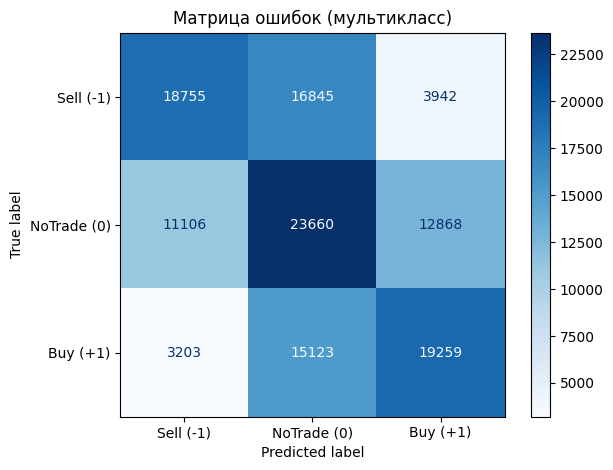

График сохранен: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/plots/class_distribution_mcl.png


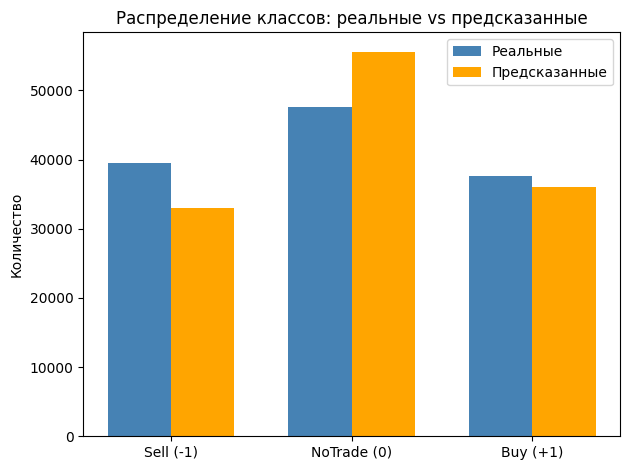

График сохранен: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/plots/softmax_confidence_mcl.png


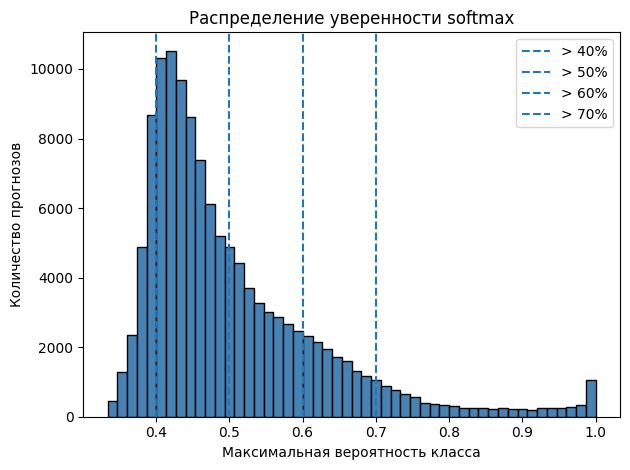

График сохранен: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/plots/loss.png


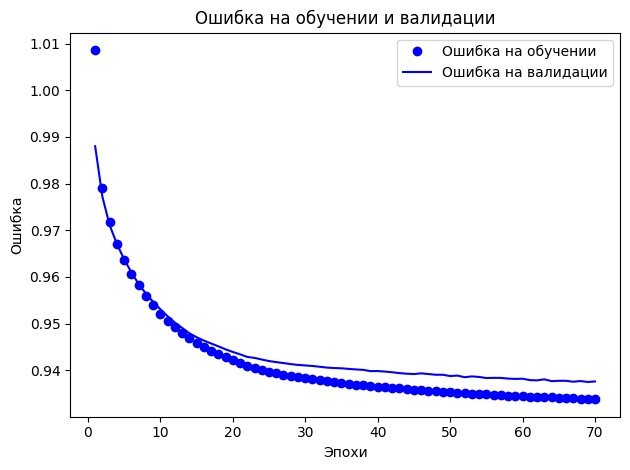

График сохранен: /home/ubuntu/NeiroNetwork/Files/WeightTF_DS/plots/accuracy.png


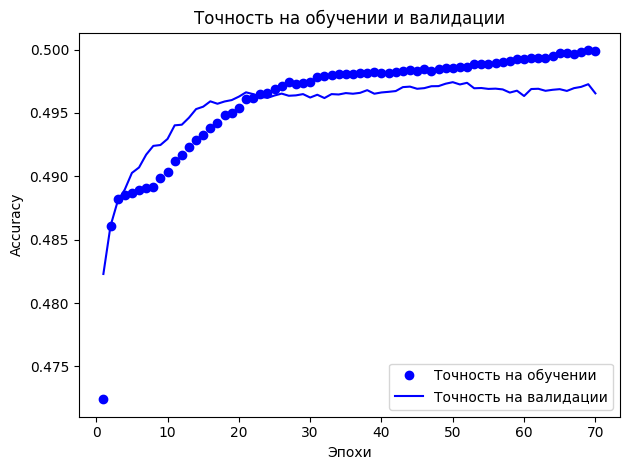

In [1]:
import main

history = main.main()
main.plot_training_history(history)

In [2]:
main.export_model(save_keras=True, save_ONNX=True, model_name="model")

INFO:tensorflow:Assets written to: exports/model_SavedModel/assets


2026-07-11 17:54:54,937 - WARNING - ***IMPORTANT*** Installed protobuf is not cpp accelerated. Conversion will be extremely slow. See https://github.com/onnx/tensorflow-onnx/issues/1557
2026-07-11 17:54:54,939 - WARNING - '--tag' not specified for saved_model. Using --tag serve
2026-07-11 17:54:55,741 - INFO - Signatures found in model: [serving_default].
2026-07-11 17:54:55,741 - WARNING - '--signature_def' not specified, using first signature: serving_default
2026-07-11 17:54:55,741 - INFO - Output names: ['dense_3']
2026-07-11 17:54:55.748591: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-07-11 17:54:55.748767: I tensorflow/core/grappler/clusters/single_machine.cc:358] Starting new session
2026-07-11 17:54:55.862157: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was

In [3]:
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession("exports/model.onnx")

input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

x_sample = main.X_test[:10].astype(np.float32)

keras_pred = main.model.predict(x_sample, verbose=0)
onnx_pred = session.run([output_name], {input_name: x_sample})[0]

print(keras_pred.ravel())
print(onnx_pred.ravel())
print(np.max(np.abs(keras_pred - onnx_pred)))

[0.710836   0.27962354 0.00954049 0.39901412 0.269643   0.33134285
 0.62894106 0.3214249  0.04963398 0.05687946 0.31048918 0.63263136
 0.68168193 0.31225532 0.00606279 0.08340716 0.32718462 0.5894083
 0.0350233  0.4618963  0.50308037 0.550611   0.43194538 0.01744364
 0.00295387 0.24492371 0.7521224  0.6772173  0.31940973 0.00337298]
[0.710836   0.27962354 0.00954049 0.39901417 0.26964307 0.3313428
 0.62894106 0.3214249  0.04963398 0.05687943 0.31048918 0.63263136
 0.681682   0.31225526 0.00606279 0.0834072  0.3271846  0.58940816
 0.03502329 0.46189636 0.50308037 0.5506111  0.43194532 0.01744364
 0.00295387 0.2449238  0.7521223  0.67721725 0.31940973 0.00337298]
1.1920929e-07


In [4]:
import numpy as np
from config import TASK

# -----------------------------
# Настройки анализа
# -----------------------------

THRESHOLDS_MULTICLASS = [0.00, 0.33, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
THRESHOLDS_CLASSIFICATION = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.90]
THRESHOLDS_REGRESSION = [0.00, 0.10, 0.20, 0.30, 0.40, 0.50, 0.70, 0.90]

EPS = 1e-12


def print_target_distribution(y_signals):
    print(f"Всего тестовых баров: {len(y_signals)}")
    print(f"Реальные Sell (-1):   {np.sum(y_signals == -1)}")
    print(f"Реальные NoTrade (0): {np.sum(y_signals == 0)}")
    print(f"Реальные Buy (+1):    {np.sum(y_signals == 1)}")
    print()


def print_signal_distribution(name, signals):
    print(f"{name}:")
    print(f"  Sell (-1):   {np.sum(signals == -1)}")
    print(f"  NoTrade (0): {np.sum(signals == 0)}")
    print(f"  Buy (+1):    {np.sum(signals == 1)}")
    print()


def evaluate_trade_thresholds(y_signals, pred_signals, confidence, thresholds, threshold_name):
    """
    Честная торговая оценка:
    - сделка считается только там, где модель сама дала Sell или Buy;
    - если модель дала Sell/Buy, а реальный класс NoTrade, это false positive;
    - если модель дала противоположное направление, это wrong direction;
    - win только когда направление модели совпало с реальным Sell/Buy.
    """

    print(f"{'Порог ' + threshold_name:>18} {'Сделок':>9} {'Coverage':>10} "
          f"{'Win':>9} {'Loss':>9} {'NoTrade FP':>11} {'WrongDir':>9} {'WinRate':>9}")
    print("-" * 96)

    for threshold in thresholds:
        trade_mask = (pred_signals != 0) & (confidence >= threshold)
        n = trade_mask.sum()

        if n == 0:
            continue

        pred_trades = pred_signals[trade_mask]
        true_for_trades = y_signals[trade_mask]

        wins = np.sum(pred_trades == true_for_trades)
        false_notrade = np.sum(true_for_trades == 0)
        wrong_direction = np.sum((true_for_trades != 0) & (pred_trades != true_for_trades))

        losses = false_notrade + wrong_direction
        coverage = n / len(y_signals) * 100
        win_rate = wins / n * 100

        print(
            f"{threshold:>18.2f} {n:>9} {coverage:>9.1f}% "
            f"{wins:>9} {losses:>9} {false_notrade:>11} "
            f"{wrong_direction:>9} {win_rate:>8.1f}%"
        )

    print()


def evaluate_raw_accuracy(y_signals, pred_signals):
    exact = np.mean(pred_signals == y_signals) * 100

    trade_mask = pred_signals != 0
    trade_accuracy = np.mean(pred_signals[trade_mask] == y_signals[trade_mask]) * 100 if trade_mask.any() else np.nan

    print("Базовая точность сигналов:")
    print(f"  Exact match по всем барам:       {exact:.2f}%")
    if trade_mask.any():
        print(f"  Exact match только по сделкам:   {trade_accuracy:.2f}%")
    else:
        print("  Exact match только по сделкам:   сделок нет")
    print()


def regression_to_signals(pred, threshold):
    """
    Для regression предполагаем:
    pred > +threshold -> Buy
    pred < -threshold -> Sell
    иначе NoTrade
    """
    signals = np.zeros_like(pred, dtype="int32")
    signals[pred > threshold] = 1
    signals[pred < -threshold] = -1
    return signals


# -----------------------------
# Прогноз модели
# -----------------------------

raw_pred = main.model.predict(main.X_test, verbose=0)

print(f"TASK: {TASK}")
print(f"Форма raw prediction: {raw_pred.shape}")
print()


# -----------------------------
# Multiclass: softmax [Sell, NoTrade, Buy]
# -----------------------------

if TASK == "multiclass":
    proba = raw_pred

    class_pred = np.argmax(proba, axis=1)      # 0/1/2
    pred_signals = class_pred - 1              # -1/0/+1
    confidence = proba.max(axis=1)

    y_signals = main.y_test.astype("int32") - 1

    print_target_distribution(y_signals)
    print_signal_distribution("Предсказанные сигналы", pred_signals)

    evaluate_raw_accuracy(y_signals, pred_signals)

    print("Первые 10 вероятностей [Sell, NoTrade, Buy]:")
    print(proba[:10].round(4))
    print("Первые 10 предсказанных сигналов:")
    print(pred_signals[:10])
    print()

    evaluate_trade_thresholds(
        y_signals=y_signals,
        pred_signals=pred_signals,
        confidence=confidence,
        thresholds=THRESHOLDS_MULTICLASS,
        threshold_name="softmax",
    )


# -----------------------------
# Classification: sigmoid
# -----------------------------
# ВАЖНО:
# Этот режим корректен только если binary target действительно 0/1.
# Если Target1 содержит -1/0/+1, сначала надо решить, что означает binary:
#   1) Trade vs NoTrade
#   2) Buy vs Sell
#   3) Buy vs not-Buy
#
# Ниже универсальная интерпретация:
# probability >= threshold -> Buy (+1)
# probability < threshold  -> Sell (-1)
# NoTrade в binary-модели не предсказывается.

elif TASK == "classification":
    proba_buy = raw_pred.ravel()
    y_raw = main.y_test.astype("float32").ravel()

    unique_y = set(np.unique(y_raw))

    if unique_y.issubset({0.0, 1.0}):
        # 0 -> Sell, 1 -> Buy
        y_signals = np.where(y_raw >= 0.5, 1, -1).astype("int32")
    elif unique_y.issubset({-1.0, 0.0, 1.0}):
        # Если сюда попали -1/0/+1, показываем предупреждение и анализируем как есть.
        # Но binary-модель не умеет честно предсказывать NoTrade.
        y_signals = y_raw.astype("int32")
        print("ВНИМАНИЕ: y_test содержит -1/0/+1, а TASK='classification'.")
        print("Binary sigmoid не умеет предсказывать 3 класса. Метрики будут условными.")
        print()
    else:
        raise ValueError(f"Неожиданные значения y_test для classification: {sorted(unique_y)}")

    print_target_distribution(y_signals)

    print("Первые 10 вероятностей Buy:")
    print(proba_buy[:10].round(4))
    print()

    print(f"{'Порог Buy':>10} {'Buy':>9} {'Sell':>9} {'Accuracy':>10} {'Buy precision':>14} {'Sell precision':>15}")
    print("-" * 78)

    for threshold in THRESHOLDS_CLASSIFICATION:
        pred_signals = np.where(proba_buy >= threshold, 1, -1).astype("int32")

        accuracy = np.mean(pred_signals == y_signals) * 100

        buy_mask = pred_signals == 1
        sell_mask = pred_signals == -1

        buy_precision = np.mean(y_signals[buy_mask] == 1) * 100 if buy_mask.any() else np.nan
        sell_precision = np.mean(y_signals[sell_mask] == -1) * 100 if sell_mask.any() else np.nan

        print(
            f"{threshold:>10.2f} {buy_mask.sum():>9} {sell_mask.sum():>9} "
            f"{accuracy:>9.1f}% {buy_precision:>13.1f}% {sell_precision:>14.1f}%"
        )

    print()


# -----------------------------
# Regression: continuous prediction
# -----------------------------
# Интерпретация:
# pred > +threshold -> Buy
# pred < -threshold -> Sell
# иначе NoTrade.
#
# Если Target2 непрерывный, для оценки направления используем sign(Target2).
# Если Target2 уже -1/0/+1, используем его напрямую.

elif TASK == "regression":
    pred = raw_pred.ravel()
    y_raw = main.y_test.astype("float32").ravel()

    unique_y = set(np.unique(y_raw))

    if unique_y.issubset({-1.0, 0.0, 1.0}):
        y_signals = y_raw.astype("int32")
    else:
        y_signals = np.zeros_like(y_raw, dtype="int32")
        y_signals[y_raw > 0] = 1
        y_signals[y_raw < 0] = -1

    abs_pred = np.abs(pred)

    print_target_distribution(y_signals)

    print("Статистика regression prediction:")
    print(f"  min:    {pred.min():.6f}")
    print(f"  max:    {pred.max():.6f}")
    print(f"  mean:   {pred.mean():.6f}")
    print(f"  std:    {pred.std():.6f}")
    print(f"  median: {np.median(pred):.6f}")
    print()

    print("Первые 10 прогнозов:")
    print(pred[:10].round(6))
    print()

    # Для regression порог одновременно задает:
    # - минимальную силу прогноза;
    # - границу NoTrade.
    print(f"{'Порог |pred|':>14} {'Сделок':>9} {'Coverage':>10} "
          f"{'Win':>9} {'Loss':>9} {'NoTrade FP':>11} {'WrongDir':>9} {'WinRate':>9}")
    print("-" * 96)

    for threshold in THRESHOLDS_REGRESSION:
        pred_signals = regression_to_signals(pred, threshold)
        trade_mask = pred_signals != 0
        n = trade_mask.sum()

        if n == 0:
            continue

        pred_trades = pred_signals[trade_mask]
        true_for_trades = y_signals[trade_mask]

        wins = np.sum(pred_trades == true_for_trades)
        false_notrade = np.sum(true_for_trades == 0)
        wrong_direction = np.sum((true_for_trades != 0) & (pred_trades != true_for_trades))

        losses = false_notrade + wrong_direction
        coverage = n / len(y_signals) * 100
        win_rate = wins / n * 100

        print(
            f"{threshold:>14.2f} {n:>9} {coverage:>9.1f}% "
            f"{wins:>9} {losses:>9} {false_notrade:>11} "
            f"{wrong_direction:>9} {win_rate:>8.1f}%"
        )

    print()

else:
    raise ValueError(f"Неизвестный TASK: {TASK!r}")

TASK: multiclass
Форма raw prediction: (124761, 3)

Всего тестовых баров: 124761
Реальные Sell (-1):   39542
Реальные NoTrade (0): 47634
Реальные Buy (+1):    37585

Предсказанные сигналы:
  Sell (-1):   33064
  NoTrade (0): 55628
  Buy (+1):    36069

Базовая точность сигналов:
  Exact match по всем барам:       49.43%
  Exact match только по сделкам:   54.99%

Первые 10 вероятностей [Sell, NoTrade, Buy]:
[[0.7108 0.2796 0.0095]
 [0.399  0.2696 0.3313]
 [0.6289 0.3214 0.0496]
 [0.0569 0.3105 0.6326]
 [0.6817 0.3123 0.0061]
 [0.0834 0.3272 0.5894]
 [0.035  0.4619 0.5031]
 [0.5506 0.4319 0.0174]
 [0.003  0.2449 0.7521]
 [0.6772 0.3194 0.0034]]
Первые 10 предсказанных сигналов:
[-1 -1 -1  1 -1  1  1 -1  1 -1]

     Порог softmax    Сделок   Coverage       Win      Loss  NoTrade FP  WrongDir   WinRate
------------------------------------------------------------------------------------------------
              0.00     69133      55.4%     38014     31119       23974      7145     55.0%
 